In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("csv/cs-training.csv")
df.head(5)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [6]:
df = df.drop(columns=["Unnamed: 0"])

In [7]:
df.shape

(150000, 11)

In [8]:
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='str')

In [9]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

We analyze how much those Nan represent.

In [11]:
(df.isnull().sum() / len(df)) * 100

SeriousDlqin2yrs                         0.000000
RevolvingUtilizationOfUnsecuredLines     0.000000
age                                      0.000000
NumberOfTime30-59DaysPastDueNotWorse     0.000000
DebtRatio                                0.000000
MonthlyIncome                           19.820667
NumberOfOpenCreditLinesAndLoans          0.000000
NumberOfTimes90DaysLate                  0.000000
NumberRealEstateLoansOrLines             0.000000
NumberOfTime60-89DaysPastDueNotWorse     0.000000
NumberOfDependents                       2.616000
dtype: float64

Missing Values and Data Imputation

Missing values were found in MonthlyIncome and NumberOfDependents. Since machine learning models cannot handle NaN values, data imputation was applied.
MonthlyIncome was filled with the median to reduce the effect of outliers, while NumberOfDependents was filled with 0, assuming missing values indicate no reported dependents.
After this step, the dataset contains no missing values.
This approach corresponds to univariate imputation, a common and simple strategy for handling missing numerical data, and it is appropriate here since the proportion of missing values is relatively small.

In [12]:
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())

In [13]:
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(0)

In [14]:
df.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

Target Variable

The variable SeriousDlqin2yrs is selected as the target variable because it represents the outcome we want to predict. It indicates whether a person experienced a serious delinquency (default) within the next two years.

In [ ]:
df["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Class Distribution

The distribution of the target variable shows a clear class imbalance. Most observations correspond to class 0 (no delinquency), while a much smaller proportion corresponds to class 1 (serious delinquency). This imbalance is important because it can affect the performance of machine learning models, which may become biased toward predicting the majority class.

<Axes: xlabel='SeriousDlqin2yrs'>

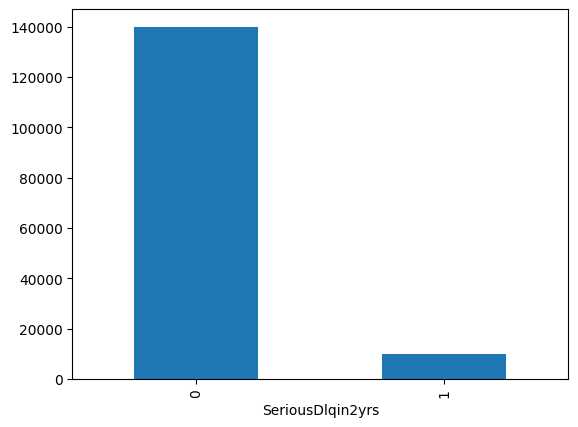

In [17]:
df["SeriousDlqin2yrs"].value_counts().plot(kind="bar")

Separate variables and target

In [18]:
X = df.drop("SeriousDlqin2yrs", axis=1)
y = df["SeriousDlqin2yrs"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

SeriousDlqin2yrs
0    0.933167
1    0.066833
Name: proportion, dtype: float64

The target variable SeriousDlqin2yrs is highly imbalanced.
Around 93% of the observations correspond to class 0 (no default) and 7% to class 1 (default).
Therefore, stratified train-test splitting was used to preserve the class distribution in both training and test sets.